# Attempt 1

In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Adult dataset path

col_names = ['Age','Work_Class','Final_Weight','Education','Education_Num',
             'Marital_Status','Occupation','Relationship','Race','Sex',
             'Capital_Gain','Capital_Loss','Hours_Per_Week','Native_Country','Target']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

adult_dataset = pd.read_csv(url, names = col_names)

In [3]:
adult_dataset.head(10)

,Age,Work_Class,Final_Weight,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


## Data Overview

In [4]:
# replaced ? with outputs that had the highest volume per column.

adult_dataset['Work_Class'] = adult_dataset['Work_Class'].replace(' ?',' Private')
adult_dataset['Occupation'] = adult_dataset['Occupation'].replace(' ?',' Prof-specialty')
adult_dataset['Native_Country'] = adult_dataset['Native_Country'].replace(' ?',' United-States')

In [5]:
adult_dataset.head(10)

,Age,Work_Class,Final_Weight,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [6]:
adult_dataset['Work_Class'].value_counts()

 Private             24532
 Self-emp-not-inc     2541
 Local-gov            2093
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: Work_Class, dtype: int64

In [7]:
adult_dataset['Occupation'].value_counts()

 Prof-specialty       5983
 Craft-repair         4099
 Exec-managerial      4066
 Adm-clerical         3770
 Sales                3650
 Other-service        3295
 Machine-op-inspct    2002
 Transport-moving     1597
 Handlers-cleaners    1370
 Farming-fishing       994
 Tech-support          928
 Protective-serv       649
 Priv-house-serv       149
 Armed-Forces            9
Name: Occupation, dtype: int64

In [8]:
adult_dataset['Native_Country'].value_counts()

 United-States                 29753
 Mexico                          643
 Philippines                     198
 Germany                         137
 Canada                          121
 Puerto-Rico                     114
 El-Salvador                     106
 India                           100
 Cuba                             95
 England                          90
 Jamaica                          81
 South                            80
 China                            75
 Italy                            73
 Dominican-Republic               70
 Vietnam                          67
 Guatemala                        64
 Japan                            62
 Poland                           60
 Columbia                         59
 Taiwan                           51
 Haiti                            44
 Iran                             43
 Portugal                         37
 Nicaragua                        34
 Peru                             31
 France                           29
 

In [9]:
adult_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Work_Class      32561 non-null  object
 2   Final_Weight    32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education_Num   32561 non-null  int64 
 5   Marital_Status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital_Gain    32561 non-null  int64 
 11  Capital_Loss    32561 non-null  int64 
 12  Hours_Per_Week  32561 non-null  int64 
 13  Native_Country  32561 non-null  object
 14  Target          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
adult_dataset.isnull().sum()

Age               0
Work_Class        0
Final_Weight      0
Education         0
Education_Num     0
Marital_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_Per_Week    0
Native_Country    0
Target            0
dtype: int64

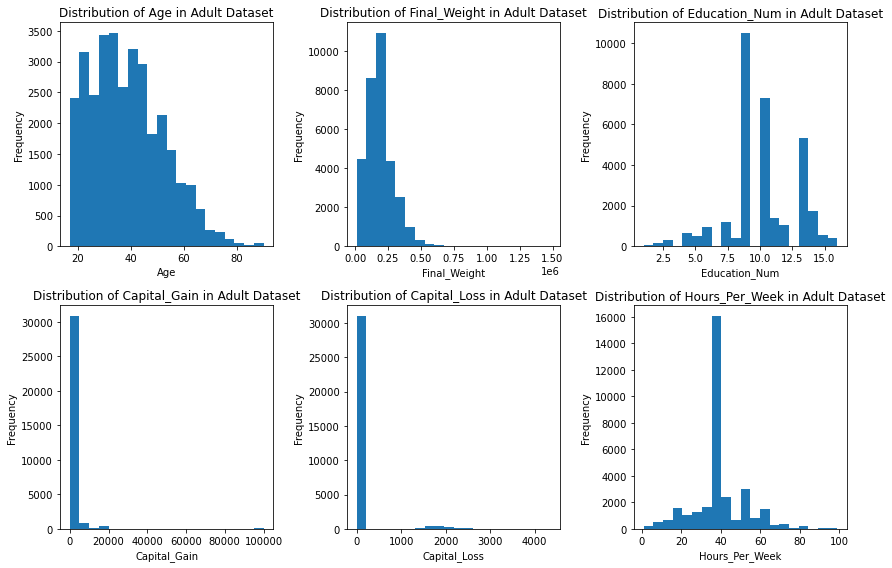

In [11]:
# Plot histograms for numerical columns in a 3x3 grid layout
num_cols = adult_dataset.select_dtypes(include=['int64', 'float64']).columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    ax.hist(adult_dataset[col], bins=20)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col} in Adult Dataset')
plt.tight_layout()
plt.show()

<AxesSubplot:>

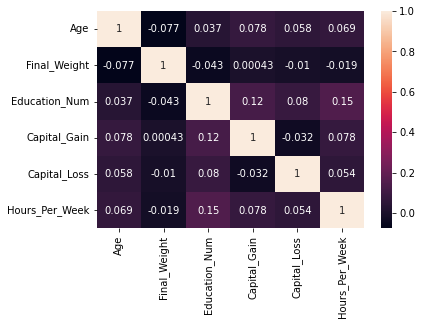

In [12]:
sns.heatmap(adult_dataset.corr(), annot=True)

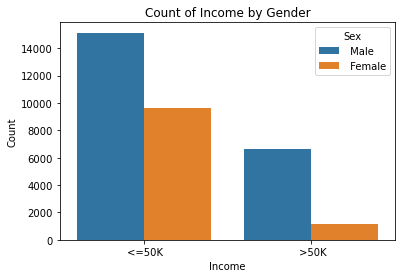

In [13]:
sns.countplot(x='Target', hue='Sex', data=adult_dataset)
plt.title('Count of Income by Gender')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

In [14]:
## Preprocessing of Data

In [15]:
from sklearn import preprocessing

# encode categorical variables using label Encoder

# select all categorical variables
adult_dataset_categorical = adult_dataset.select_dtypes(include=['object'])
adult_dataset_categorical.head()

,Work_Class,Education,Marital_Status,Occupation,Relationship,Race,Sex,Native_Country,Target
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [16]:
# apply label encoder to df_categorical
le = preprocessing.LabelEncoder()
adult_dataset_categorical = adult_dataset_categorical.apply(le.fit_transform)
adult_dataset_categorical.head(10)

,Work_Class,Education,Marital_Status,Occupation,Relationship,Race,Sex,Native_Country,Target
0,6,9,4,0,1,4,1,38,0
1,5,9,2,3,0,4,1,38,0
2,3,11,0,5,1,4,1,38,0
3,3,1,2,5,0,2,1,38,0
4,3,9,2,9,5,2,0,4,0
5,3,12,2,3,5,4,0,38,0
6,3,6,3,7,1,2,0,22,0
7,5,11,2,3,0,4,1,38,1
8,3,12,4,9,1,4,0,38,1
9,3,9,2,3,0,4,1,38,1


In [17]:
adult_dataset_categorical['Target'].value_counts()

0    24720
1     7841
Name: Target, dtype: int64

In [18]:
df = adult_dataset.drop(adult_dataset_categorical.columns,axis=1)
df = pd.concat([df,adult_dataset_categorical],axis=1)
df.head()

,Age,Final_Weight,Education_Num,Capital_Gain,Capital_Loss,Hours_Per_Week,Work_Class,Education,Marital_Status,Occupation,Relationship,Race,Sex,Native_Country,Target
0,39,77516,13,2174,0,40,6,9,4,0,1,4,1,38,0
1,50,83311,13,0,0,13,5,9,2,3,0,4,1,38,0
2,38,215646,9,0,0,40,3,11,0,5,1,4,1,38,0
3,53,234721,7,0,0,40,3,1,2,5,0,2,1,38,0
4,28,338409,13,0,0,40,3,9,2,9,5,2,0,4,0


In [19]:
# Importing train_test_split
from sklearn.model_selection import train_test_split

In [20]:
# Putting independent variables/features to X
X = df.drop('Target',axis=1)

# Putting response/dependent variable/feature to y
y = df['Target']

In [21]:
# Splitting the data into train and test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=100)

X_train.head()

,Age,Final_Weight,Education_Num,Capital_Gain,Capital_Loss,Hours_Per_Week,Work_Class,Education,Marital_Status,Occupation,Relationship,Race,Sex,Native_Country
29313,45,285060,13,0,0,50,3,9,2,3,0,4,1,38
16021,22,112130,9,0,0,40,3,11,4,7,1,2,0,38
905,46,171550,9,0,0,38,3,11,0,6,1,4,0,38
31251,22,255575,12,0,0,15,6,7,4,9,1,4,0,38
3368,40,223881,15,99999,0,70,5,14,2,9,0,4,1,38


In [22]:
# Importing decision tree classifier from sklearn library
from sklearn.tree import DecisionTreeClassifier

# Fitting the decision tree with default hyperparameters, apart from
# max_depth which is 5 so that we can plot and read the tree.
clf_entropy = DecisionTreeClassifier(criterion = "entropy", max_depth=5, min_samples_leaf=5)
clf_entropy.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5)

In [23]:
# making predictions
y_pred_en = clf_entropy.predict(X_test)
y_pred_en

array([0, 0, 0, ..., 0, 0, 0])

In [24]:
# classification report and confusion matrix 
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# classifier report
print(classification_report(y_test,y_pred_en))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      7428
           1       0.78      0.51      0.62      2341

    accuracy                           0.85      9769
   macro avg       0.82      0.73      0.76      9769
weighted avg       0.84      0.85      0.84      9769



In [25]:
# Printing confusion matrix and accuracy
print(confusion_matrix(y_test,y_pred_en))
print("The Accuracy is:", accuracy_score(y_test,y_pred_en)*100)

[[7089  339]
 [1140 1201]]
The Accuracy is: 84.86027228989661


## Plotting the Decision Tree (1) to Visualize the Model

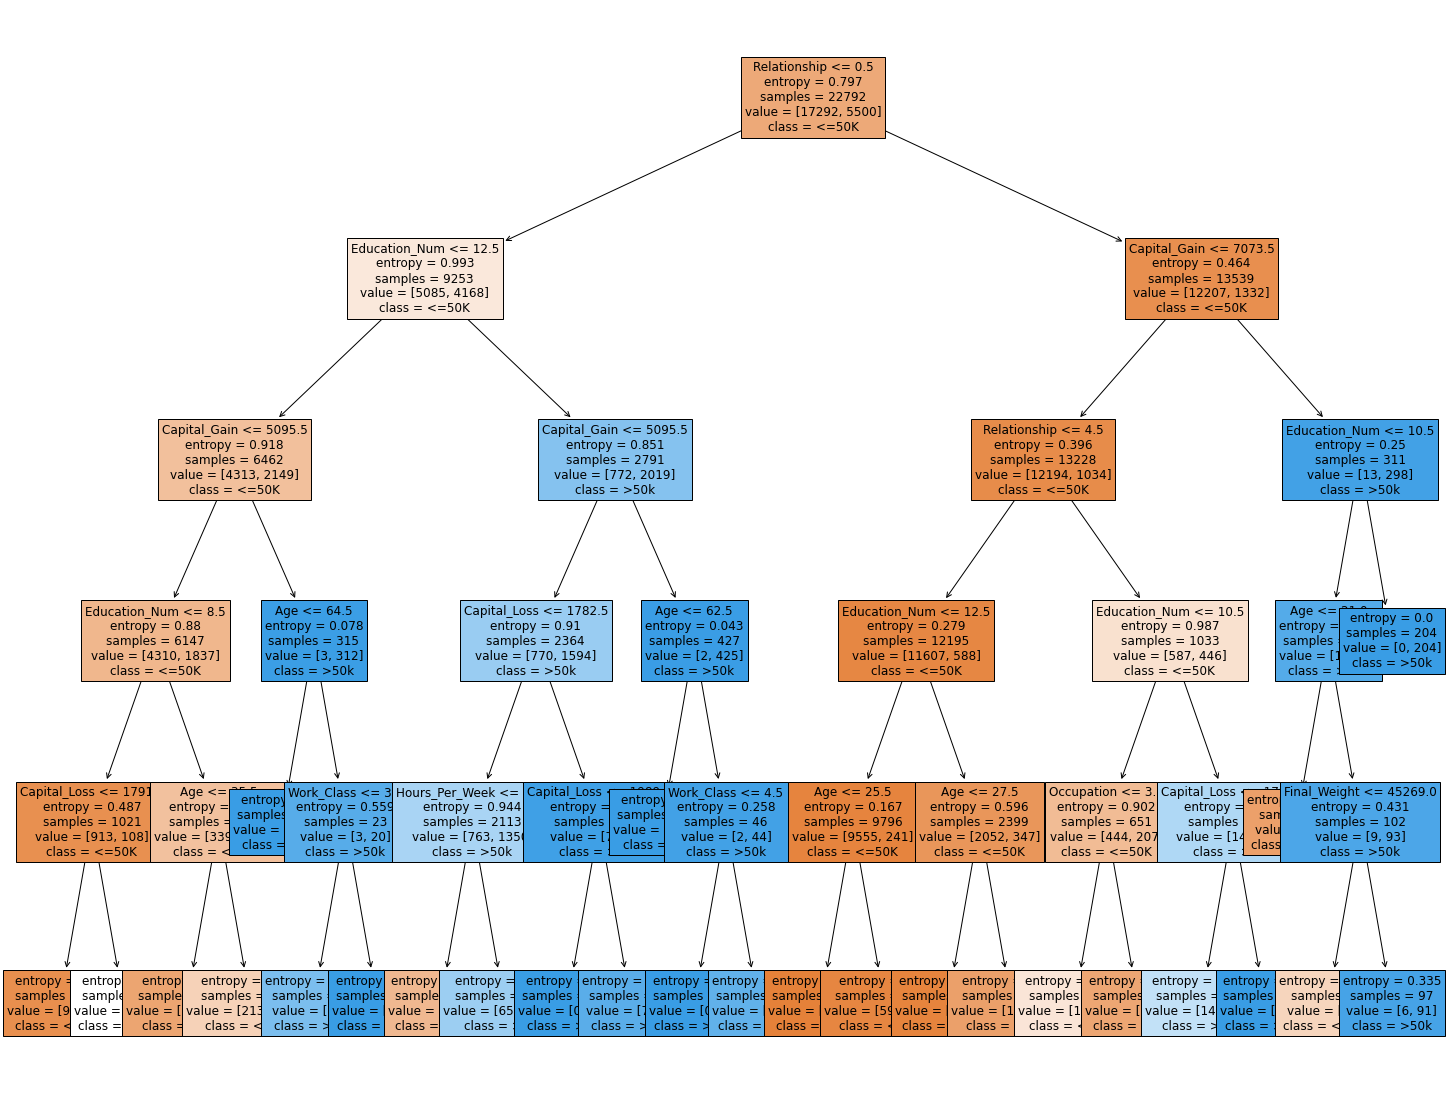

In [26]:
from sklearn import tree

feature_names = X.columns

dt_fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(clf_entropy,
                  feature_names=feature_names,
                  class_names={0:'<=50K', 1: '>50k'},
                  filled=True,
                  fontsize=12)

# Attempt Number 2

#### We are using this attempt to fix the overfitting that seemed to occur in the the first attempts decision tree. Differences are the biggest with utilizing more of the decision tree parameters.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
# re-importing data, renaming in the process for attempt 2

col_names = ['Age','Work_Class','Final_Weight','Education','Education_Num',
             'Marital_Status','Occupation','Relationship','Race','Sex',
             'Capital_Gain','Capital_Loss','Hours_Per_Week','Native_Country','Target']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

income = pd.read_csv(url, names=col_names)

In [29]:
#Checking the size of the dataset

income.shape

(32561, 15)

In [30]:
income.head(40)

,Age,Work_Class,Final_Weight,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


## A Data Overview, Exploring the Data

In [31]:
income.dtypes

Age                int64
Work_Class        object
Final_Weight       int64
Education         object
Education_Num      int64
Marital_Status    object
Occupation        object
Relationship      object
Race              object
Sex               object
Capital_Gain       int64
Capital_Loss       int64
Hours_Per_Week     int64
Native_Country    object
Target            object
dtype: object

In [32]:
income.isnull().sum()

Age               0
Work_Class        0
Final_Weight      0
Education         0
Education_Num     0
Marital_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_Per_Week    0
Native_Country    0
Target            0
dtype: int64

In [33]:
income.isna().sum()

Age               0
Work_Class        0
Final_Weight      0
Education         0
Education_Num     0
Marital_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_Per_Week    0
Native_Country    0
Target            0
dtype: int64

In [34]:
income.describe().round(2)

,Age,Final_Weight,Education_Num,Capital_Gain,Capital_Loss,Hours_Per_Week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [35]:
income.nunique()

Age                  73
Work_Class            9
Final_Weight      21648
Education            16
Education_Num        16
Marital_Status        7
Occupation           15
Relationship          6
Race                  5
Sex                   2
Capital_Gain        119
Capital_Loss         92
Hours_Per_Week       94
Native_Country       42
Target                2
dtype: int64

In [36]:
income['Work_Class'].value_counts()

 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
 ?                    1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: Work_Class, dtype: int64

In [37]:
income['Occupation'].value_counts()

 Prof-specialty       4140
 Craft-repair         4099
 Exec-managerial      4066
 Adm-clerical         3770
 Sales                3650
 Other-service        3295
 Machine-op-inspct    2002
 ?                    1843
 Transport-moving     1597
 Handlers-cleaners    1370
 Farming-fishing       994
 Tech-support          928
 Protective-serv       649
 Priv-house-serv       149
 Armed-Forces            9
Name: Occupation, dtype: int64

In [38]:
income['Target'].value_counts()

 <=50K    24720
 >50K      7841
Name: Target, dtype: int64

In [39]:
income['Native_Country'].value_counts()

 United-States                 29170
 Mexico                          643
 ?                               583
 Philippines                     198
 Germany                         137
 Canada                          121
 Puerto-Rico                     114
 El-Salvador                     106
 India                           100
 Cuba                             95
 England                          90
 Jamaica                          81
 South                            80
 China                            75
 Italy                            73
 Dominican-Republic               70
 Vietnam                          67
 Guatemala                        64
 Japan                            62
 Poland                           60
 Columbia                         59
 Taiwan                           51
 Haiti                            44
 Iran                             43
 Portugal                         37
 Nicaragua                        34
 Peru                             31
 

In [40]:
# used this to determine of all columns, how many have a ? of the total. Seems to be 2399 of 32561, 7.4%.

qmarks = income[income.isin([' ?']).any(axis=1)]


In [41]:
# used to generate the percent of data with '?'s.

qmarks.shape[0]/len(income) * 100

7.367709836921471

In [42]:
# replacing missing values with most frequent value per column.

income['Work_Class'] = income['Work_Class'].replace(' ?',' Private')
income['Occupation'] = income['Occupation'].replace(' ?',' Prof-specialty')
income['Native_Country'] = income['Native_Country'].replace(' ?',' United-States')

In [43]:
#turning the target column into binary values

income['Target'] = income['Target'].apply(lambda x: 1 if x == ' >50K' else 0)

In [44]:
income['Target'].value_counts()

0    24720
1     7841
Name: Target, dtype: int64

In [45]:
income.dtypes

Age                int64
Work_Class        object
Final_Weight       int64
Education         object
Education_Num      int64
Marital_Status    object
Occupation        object
Relationship      object
Race              object
Sex               object
Capital_Gain       int64
Capital_Loss       int64
Hours_Per_Week     int64
Native_Country    object
Target             int64
dtype: object

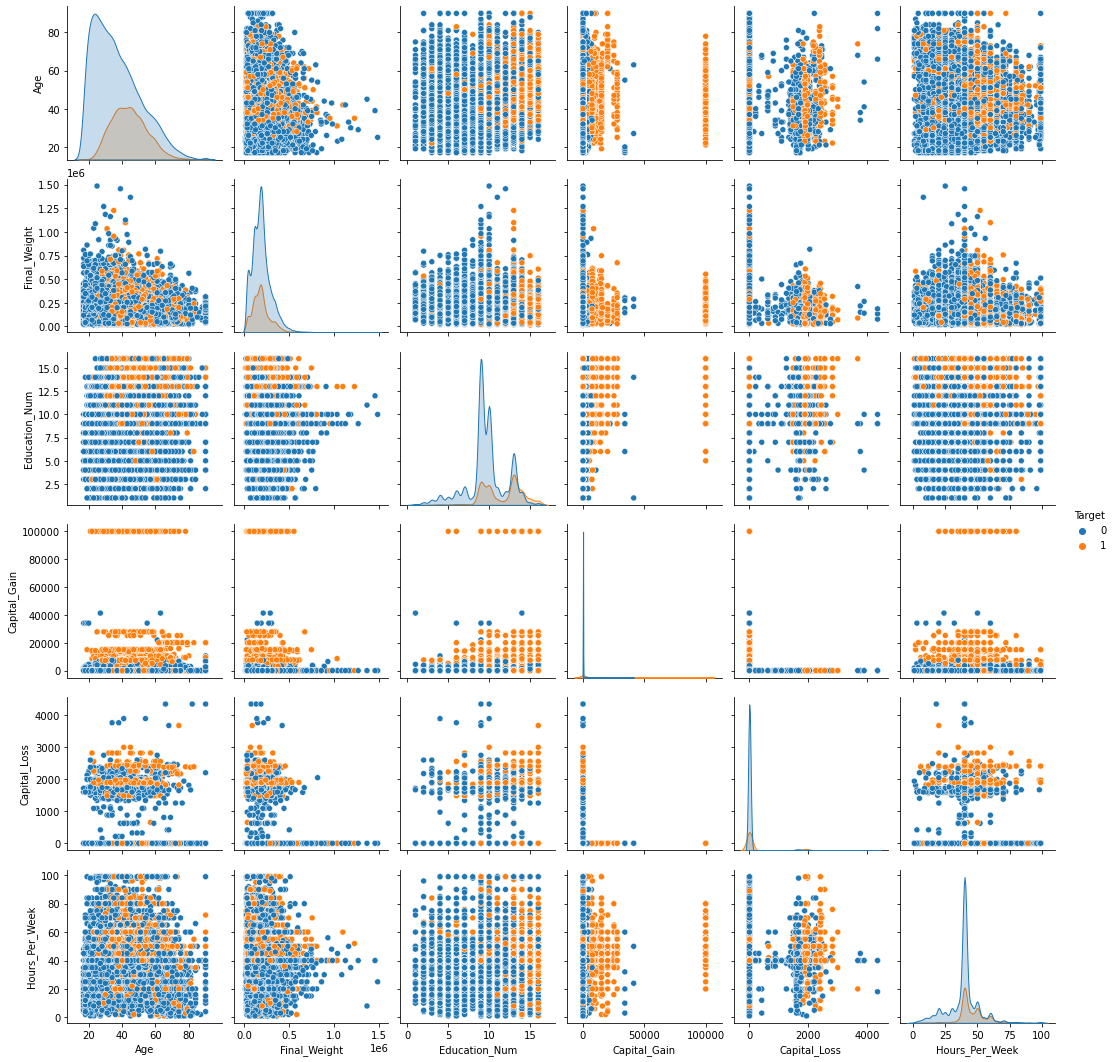

In [46]:
# analzying the data visually
sns.pairplot(income, hue='Target')

## Preprocessing and Data Cleaning

In [47]:
#turning the target column into binary values

income['Sex'] = income['Sex'].apply(lambda x: 1 if x == ' Male' else 0)

In [48]:
#dropping education because we have Education_Num which maps to the corresponding categorical column, Education.

income.drop('Education', axis=1, inplace=True)

In [49]:
income.head(20) #checking to make sure it worked

,Age,Work_Class,Final_Weight,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,13,United-States,0
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,1,0,0,40,United-States,0
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,0,0,40,United-States,0
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,0,40,Cuba,0
5,37,Private,284582,14,Married-civ-spouse,Exec-managerial,Wife,White,0,0,0,40,United-States,0
6,49,Private,160187,5,Married-spouse-absent,Other-service,Not-in-family,Black,0,0,0,16,Jamaica,0
7,52,Self-emp-not-inc,209642,9,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,45,United-States,1
8,31,Private,45781,14,Never-married,Prof-specialty,Not-in-family,White,0,14084,0,50,United-States,1
9,42,Private,159449,13,Married-civ-spouse,Exec-managerial,Husband,White,1,5178,0,40,United-States,1


In [50]:
income['Target'].value_counts() #double checking that things are still accurate and things were done correctly.

0    24720
1     7841
Name: Target, dtype: int64

In [51]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [52]:
income

,Age,Work_Class,Final_Weight,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,13,United-States,0
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,1,0,0,40,United-States,0
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,0,0,40,United-States,0
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,12,Married-civ-spouse,Tech-support,Wife,White,0,0,0,38,United-States,0
32557,40,Private,154374,9,Married-civ-spouse,Machine-op-inspct,Husband,White,1,0,0,40,United-States,1
32558,58,Private,151910,9,Widowed,Adm-clerical,Unmarried,White,0,0,0,40,United-States,0
32559,22,Private,201490,9,Never-married,Adm-clerical,Own-child,White,1,0,0,20,United-States,0


In [53]:
# label encoding

cat_cols = ['Work_Class','Marital_Status','Occupation','Relationship','Race','Native_Country']  # list of categorical column names

le = LabelEncoder()

for col in cat_cols:
    income[col] = le.fit_transform(income[col]) 

#features

X = income.drop('Target', axis=1) 

#target

y = income['Target']


In [54]:
X

,Age,Work_Class,Final_Weight,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country
0,39,6,77516,13,4,0,1,4,1,2174,0,40,38
1,50,5,83311,13,2,3,0,4,1,0,0,13,38
2,38,3,215646,9,0,5,1,4,1,0,0,40,38
3,53,3,234721,7,2,5,0,2,1,0,0,40,38
4,28,3,338409,13,2,9,5,2,0,0,0,40,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,3,257302,12,2,12,5,4,0,0,0,38,38
32557,40,3,154374,9,2,6,0,4,1,0,0,40,38
32558,58,3,151910,9,6,0,4,4,0,0,0,40,38
32559,22,3,201490,9,4,0,3,4,1,0,0,20,38


## Building/Testing decision tree classifier.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=88, stratify=y)


In [56]:
# creating the DecisionTreeClassifier object and fitting it to the training data
# added a leaf node size to try and reduce overfitting. 7 because it was less leaf nodes than in attempt 1.

dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, max_features=.8, min_samples_split=3,
                            random_state=88, max_leaf_nodes=5)

dt.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, max_features=0.8,
                       max_leaf_nodes=5, min_samples_split=3, random_state=88)

In [57]:
#predicting

y_proba = dt.predict_proba(X_test)[:,1]

y_pred = dt.predict(X_test)

In [58]:
print(y_pred)

[0 0 0 ... 0 0 1]


## Assessing the accuracy of Attempt 2.

In [59]:
# creating a confusion matrix to assess accuracy

cm = metrics.confusion_matrix(y_test, y_pred) 

income_cm = pd.DataFrame(data=cm, columns=['predict: <=50K', 'predict: >50K'],
                    index=['true: <=50K', 'true: >50K'])

income_cm


,predict: <=50K,predict: >50K
true: <=50K,7086,331
true: >50K,1229,1123


In [60]:
#accuracy metrics

print(metrics.classification_report(y_test, y_pred))

print('The Accuracy is ', metrics.accuracy_score(y_test,y_pred))

# slight decrease from attempt 1's, but no overfitting.

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      7417
           1       0.77      0.48      0.59      2352

    accuracy                           0.84      9769
   macro avg       0.81      0.72      0.75      9769
weighted avg       0.83      0.84      0.83      9769

The Accuracy is  0.8403111884532706


## Visualization of Decision Tree 2

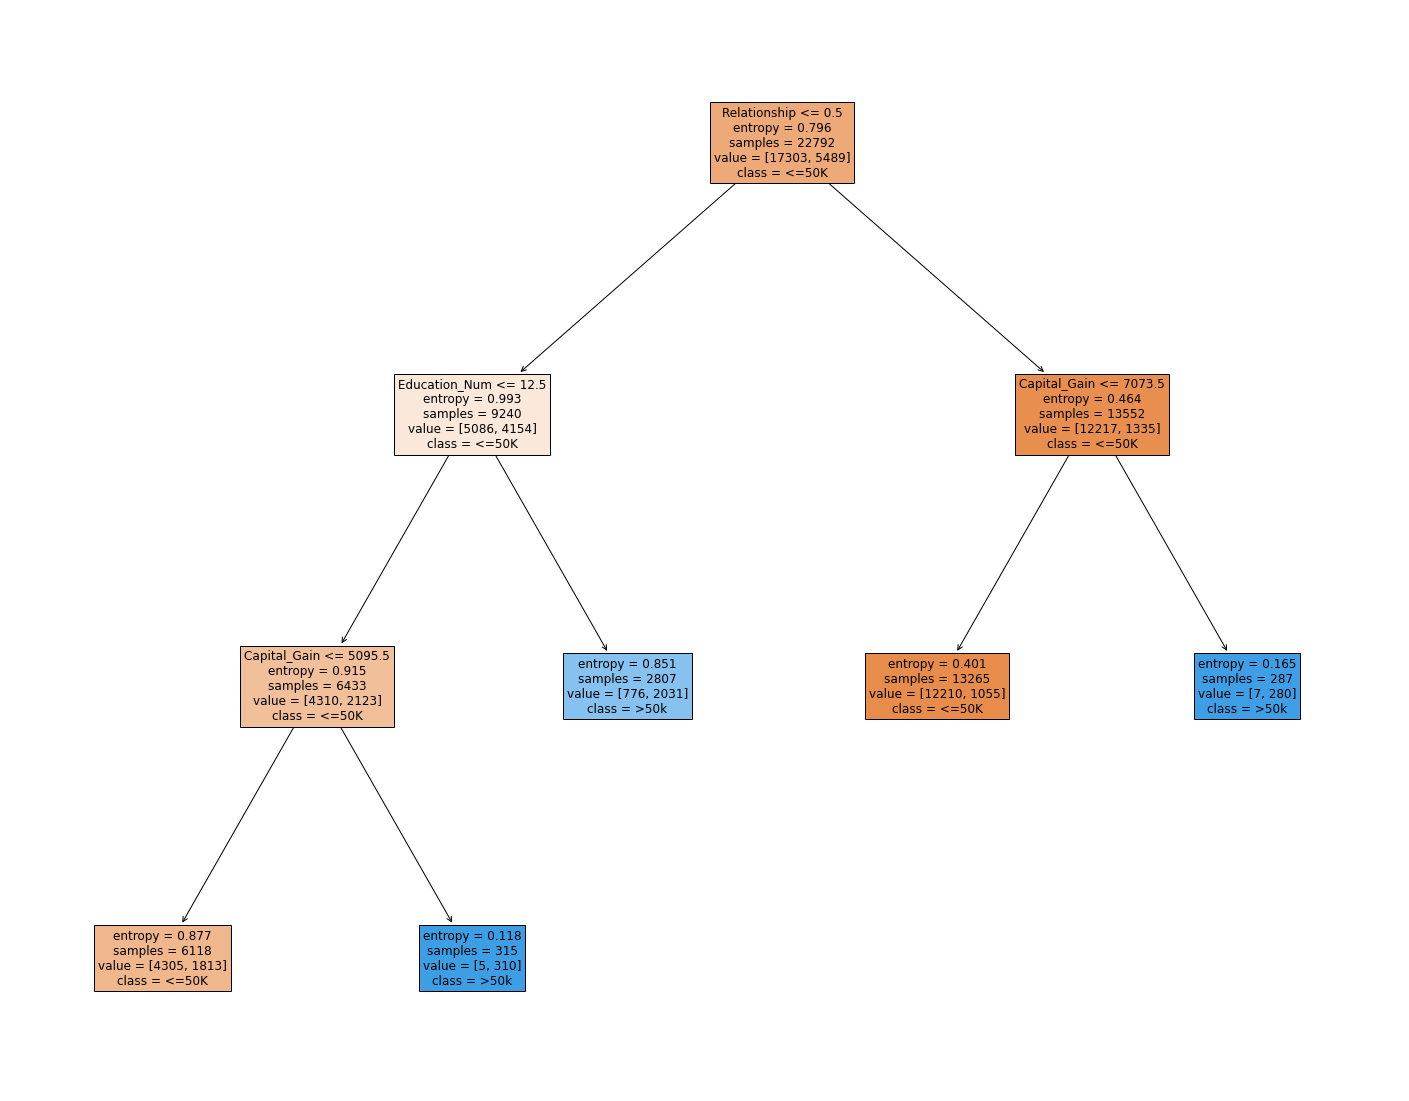

In [61]:
from sklearn import tree

feature_names = X.columns

dt_fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dt,
                  feature_names=feature_names,
                  class_names={0:'<=50K', 1: '>50k'},
                  filled=True,
                  fontsize=12)

##  Feature Analysis of Decision Tree Model 2

In [62]:
# trying to understand which features we should remove before rerunning the model.

feature_names = X.columns
# feature_names

dt.feature_importances_
# is something wrong? There are only 1 columns showing significant importance, every time.

array([0.        , 0.        , 0.        , 0.17963743, 0.        ,
       0.        , 0.53736774, 0.        , 0.        , 0.28299483,
       0.        , 0.        , 0.        ])

<AxesSubplot:>

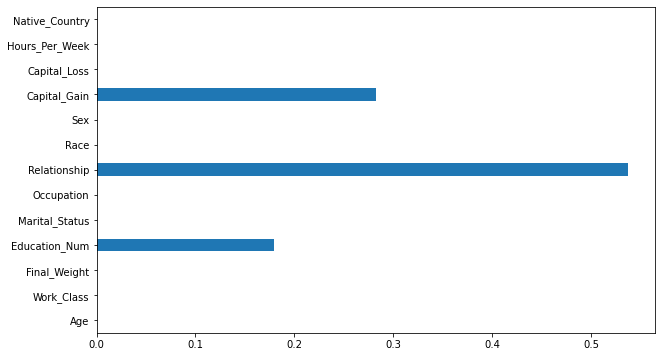

In [63]:
plt.figure(figsize=(10, 6))

feat_importances = pd.Series(dt.feature_importances_, index=X.columns)
feat_importances.plot(kind='barh')


# based on feature importance, I think we should drop native country, final weight, and possibly sex. 
# However, due to the time period of the data, i thin we should keep it.


# Attempt 3

#### Completed this attempt to improve the overall accruacy of the model since we seemed to have managed the overfitting issue.

In [64]:
# re-impporting the data due to preprocessing procedures

col_names = ['Age','Work_Class','Final_Weight','Education','Education_Num',
             'Marital_Status','Occupation','Relationship','Race','Sex',
             'Capital_Gain','Capital_Loss','Hours_Per_Week','Native_Country','Target']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

income2 = pd.read_csv(url, names=col_names)

In [65]:
# replacing missing values with most frequent value per column.

income['Work_Class'] = income['Work_Class'].replace(' ?',' Private')
income['Occupation'] = income['Occupation'].replace(' ?',' Prof-specialty')
income['Native_Country'] = income['Native_Country'].replace(' ?',' United-States')

In [66]:
#turning the target column into binary values

income2['Target'] = income2['Target'].apply(lambda x: 1 if x == ' >50K' else 0)

#turning the target column into binary values

income2['Sex'] = income2['Sex'].apply(lambda x: 1 if x == ' Male' else 0)

In [67]:
income2.dtypes

Age                int64
Work_Class        object
Final_Weight       int64
Education         object
Education_Num      int64
Marital_Status    object
Occupation        object
Relationship      object
Race              object
Sex                int64
Capital_Gain       int64
Capital_Loss       int64
Hours_Per_Week     int64
Native_Country    object
Target             int64
dtype: object

## Examining the distribution of data for the different features (attributes)

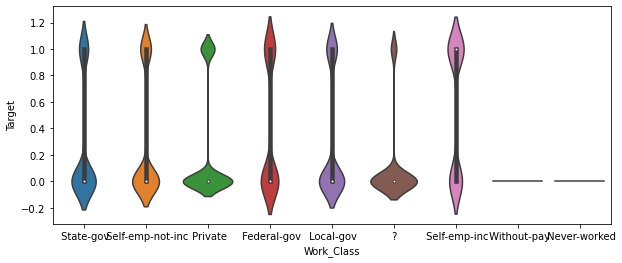

In [68]:
plt.figure(figsize=(10, 4))

sns.violinplot(x='Work_Class', y='Target', data=income2, jitter=.4, alpha=0.3)
plt.show()

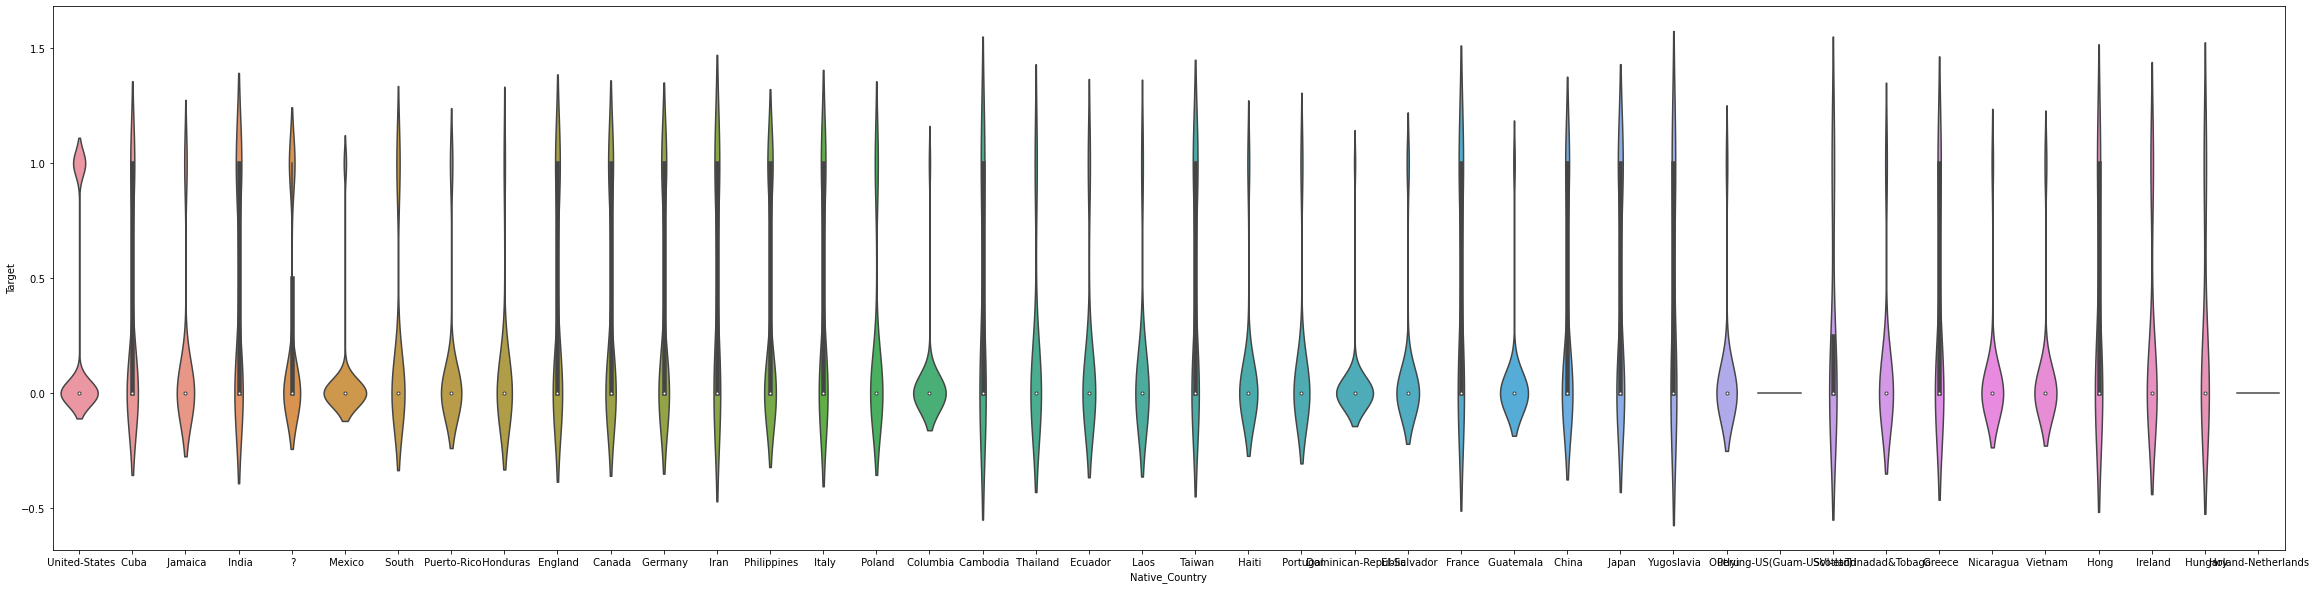

In [69]:
plt.figure(figsize=(40, 10))

sns.violinplot(x='Native_Country', y='Target', data=income2, jitter=.4, alpha=0.3)
plt.show()

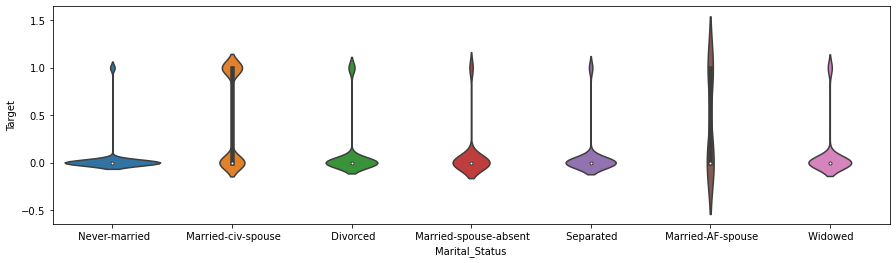

In [70]:
plt.figure(figsize=(15, 4))

sns.violinplot(x='Marital_Status', y='Target', data=income2, jitter=.4, alpha=0.3)
plt.show()

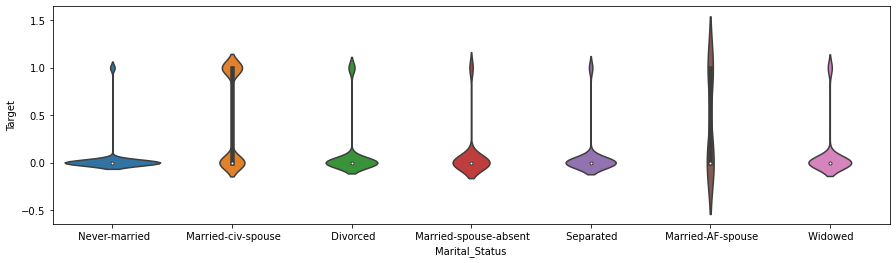

In [71]:
plt.figure(figsize=(15, 4))

sns.violinplot(x='Marital_Status', y='Target', data=income2, jitter=.4, alpha=0.3)
plt.show()

<AxesSubplot:xlabel='Target', ylabel='Hours_Per_Week'>

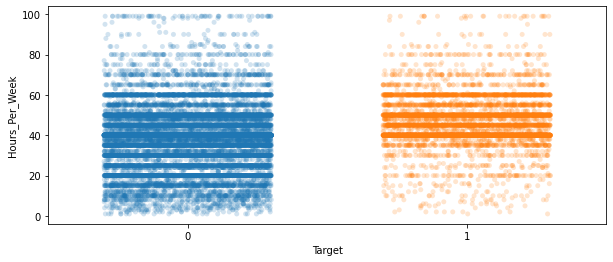

In [72]:
plt.figure(figsize=(10, 4))

sns.stripplot(x='Target', y='Hours_Per_Week', data=income2, jitter=0.3, alpha=.2)

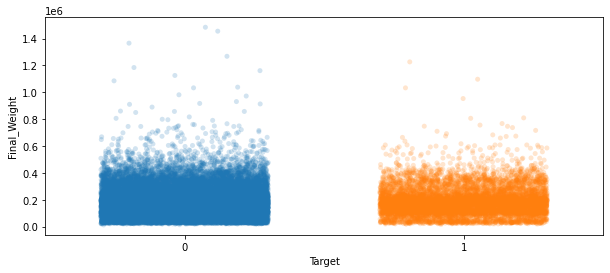

In [73]:
plt.figure(figsize=(10, 4))

sns.stripplot(x='Target', y='Final_Weight', data=income2, jitter=0.3, alpha=.2)
plt.show()

## Cleaning the Data 

In [74]:
# Dropping attributes based on exploration of data distribution

income2.drop('Education', axis=1, inplace=True)

#dropping education because we have Education_Num which maps to the corresponding categorical column, Education.

income2.drop('Final_Weight', axis=1, inplace=True)
# based on the heatmap (attempt 1) as well as distribution graphs

# income2.drop('Native_Country', axis=1, inplace=True)
# # based on the distribution graphs, its skewed for americans, likewise not deemed an important feature

In [75]:
income2

,Age,Work_Class,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,1,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,1,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,1,0,0,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,1,0,0,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,0,0,0,38,United-States,0
32557,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,1,0,0,40,United-States,1
32558,58,Private,9,Widowed,Adm-clerical,Unmarried,White,0,0,0,40,United-States,0
32559,22,Private,9,Never-married,Adm-clerical,Own-child,White,1,0,0,20,United-States,0


## Preprocessing the data for attempt 3

In [76]:
# replacing missing values with most frequent value per column.

income['Work_Class'] = income['Work_Class'].replace(' ?',' Private')
income['Occupation'] = income['Occupation'].replace(' ?',' Prof-specialty')
income['Native_Country'] = income['Native_Country'].replace(' ?',' United-States')

In [80]:
# trying a different way to preprocess the data, label encoding versus OHE to see if it also yields better results
from sklearn.preprocessing import LabelEncoder

# remaining categorical columns

cat_cols = ['Marital_Status','Occupation','Relationship','Race','Work_Class','Native_Country']  # list of categorical column names

le = LabelEncoder()

for col in cat_cols:
    income2[col] = le.fit_transform(income2[col])  

#features

X = income2.drop('Target', axis=1) 

#target

y = income2['Target']



In [81]:
income2

,Age,Work_Class,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Target
0,39,7,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,13,2,4,0,4,1,0,0,13,39,0
2,38,4,9,0,6,1,4,1,0,0,40,39,0
3,53,4,7,2,6,0,2,1,0,0,40,39,0
4,28,4,13,2,10,5,2,0,0,0,40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,12,2,13,5,4,0,0,0,38,39,0
32557,40,4,9,2,7,0,4,1,0,0,40,39,1
32558,58,4,9,6,1,4,4,0,0,0,40,39,0
32559,22,4,9,4,1,3,4,1,0,0,20,39,0


In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=90, stratify=y)


# creating the DecisionTreeClassifier object and fitting it to the training data, 
# reducing the size of the max_leaf_nodes to increase accuracy

dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features=.7, random_state=99,
                           max_leaf_nodes=5)

dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features=0.7,
                       max_leaf_nodes=5, random_state=99)

In [124]:
#predicting

y_proba = dt.predict_proba(X_test)[:,1]

y_pred = dt.predict(X_test)

print(y_pred)

[0 0 0 ... 0 0 0]


## Assessing the Accuracy of Attempt 3

In [125]:
#creating a confusion matrix to assess accruacy of the model

cm = metrics.confusion_matrix(y_test, y_pred) 

income_cm = pd.DataFrame(data=cm, columns=['predict: <=50K', 'predict: >50K'],
                    index=['true: <=50K', 'true: >50K'])

income_cm

,predict: <=50K,predict: >50K
true: <=50K,7071,346
true: >50K,1235,1117


In [126]:
# Accuracy metrics after re-assessing the model. 

print(metrics.classification_report(y_test, y_pred))

print('Accuracy = ', metrics.accuracy_score(y_test,y_pred))

# unfortunately, a decrease from attempt 2. however, no overfitting, see visual.

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      7417
           1       0.76      0.47      0.59      2352

    accuracy                           0.84      9769
   macro avg       0.81      0.71      0.74      9769
weighted avg       0.83      0.84      0.82      9769

Accuracy =  0.8381615313747569


## Feature Analysis of Decision Tree Model 3

In [127]:
# Looking for any difference between this attempt and attempt 2.

feature_names = X.columns

dt.feature_importances_


array([0.        , 0.        , 0.18098341, 0.        , 0.        ,
       0.52212019, 0.        , 0.        , 0.2968964 , 0.        ,
       0.        , 0.        ])

<AxesSubplot:>

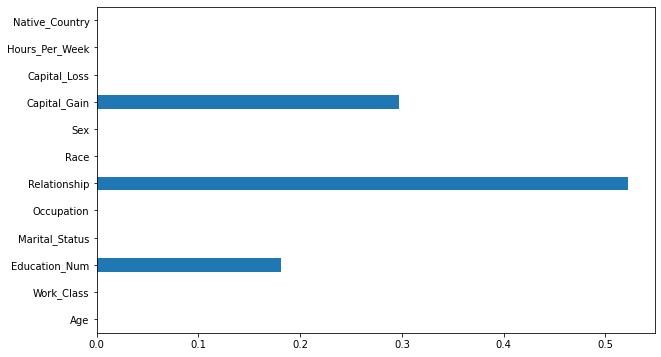

In [128]:
plt.figure(figsize=(10, 6))

feat_importances = pd.Series(dt.feature_importances_, index=X.columns)
feat_importances.plot(kind='barh')

# results show no real difference.

## Visualization of the Final Decision Tree (3)

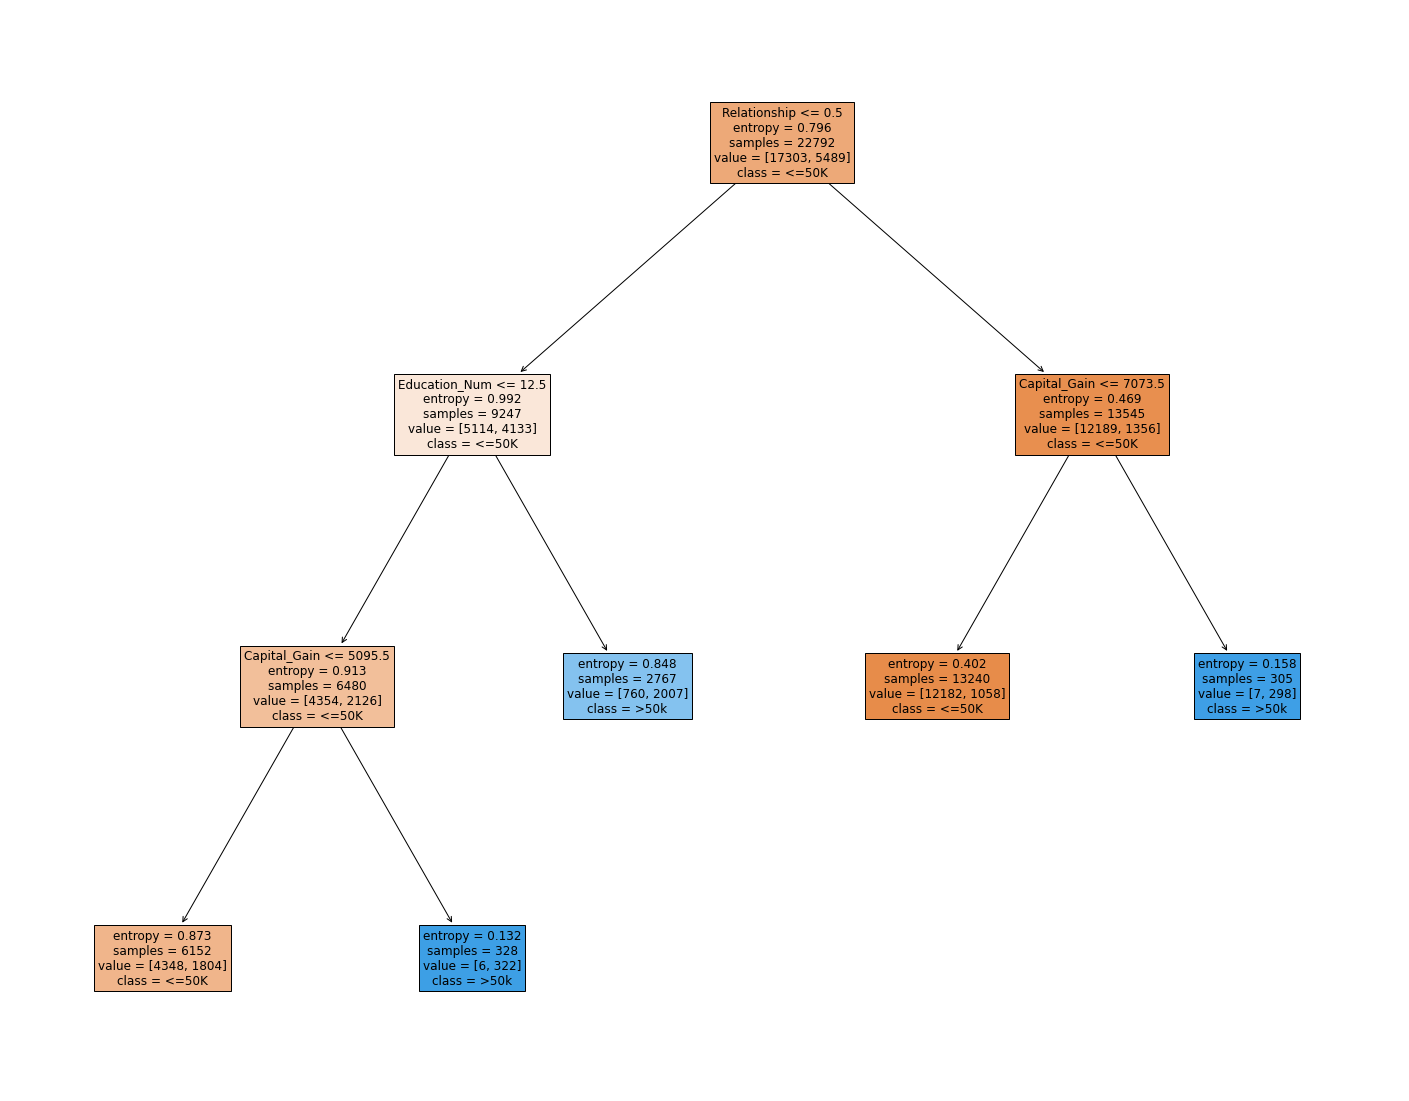

In [129]:
from sklearn import tree


dt_fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dt,
                  feature_names=feature_names,
                  class_names={0:'<=50K', 1: '>50k'},
                  filled=True,
                  fontsize=12)


In [122]:
# In total, 3 different attempts at removing features and or adjusting which decision tree classifier 
# parameters.


In [ ]:
# re-impporting the data due to preprocessing procedures

col_names = ['Age','Work_Class','Final_Weight','Education','Education_Num',
             'Marital_Status','Occupation','Relationship','Race','Sex',
             'Capital_Gain','Capital_Loss','Hours_Per_Week','Native_Country','Target']

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

income2 = pd.read_csv(url, names=col_names)

# replacing missing values with most frequent value per column.

income['Work_Class'] = income['Work_Class'].replace(' ?',' Private')
income['Occupation'] = income['Occupation'].replace(' ?',' Prof-specialty')
income['Native_Country'] = income['Native_Country'].replace(' ?',' United-States')

In [ ]:
#turning the target column into binary values

income2['Target'] = income2['Target'].apply(lambda x: 1 if x == ' >50K' else 0)

#turning the target column into binary values

income2['Sex'] = income2['Sex'].apply(lambda x: 1 if x == ' Male' else 0)

In [ ]:
# Dropping attributes based on exploration of data distribution

income2.drop('Education', axis=1, inplace=True)

#dropping education because we have Education_Num which maps to the corresponding categorical column, Education.

income2.drop('Final_Weight', axis=1, inplace=True)
# based on the heatmap (attempt 1) as well as distribution graphs

income2.drop('Native_Country', axis=1, inplace=True)
# # based on the distribution graphs, its skewed for americans, likewise not deemed an important feature



In [ ]:
# trying a different way to preprocess the data, label encoding versus OHE to see if it also yields better results
from sklearn.preprocessing import LabelEncoder

# remaining categorical columns

cat_cols = ['Marital_Status','Occupation','Relationship','Race','Work_Class','Native_Country']  # list of categorical column names

le = LabelEncoder()

for col in cat_cols:
    income2[col] = le.fit_transform(income2[col])  

#features

X = income2.drop('Target', axis=1) 

#target

y = income2['Target']



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=90, stratify=y)


# creating the DecisionTreeClassifier object and fitting it to the training data, 
# reducing the size of the max_leaf_nodes to increase accuracy

dt = DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features=.7, random_state=99,
                           max_leaf_nodes=5)

dt.fit(X_train, y_train)

In [ ]:
#predicting

y_proba = dt.predict_proba(X_test)[:,1]

y_pred = dt.predict(X_test)

print(y_pred)

In [ ]:
#creating a confusion matrix to assess accruacy of the model

cm = metrics.confusion_matrix(y_test, y_pred) 

income_cm = pd.DataFrame(data=cm, columns=['predict: <=50K', 'predict: >50K'],
                    index=['true: <=50K', 'true: >50K'])

income_cm

In [ ]:
# Accuracy metrics after re-assessing the model. 

print(metrics.classification_report(y_test, y_pred))

print('Accuracy = ', metrics.accuracy_score(y_test,y_pred))

# unfortunately, a decrease from attempt 2. however, no overfitting, see visual.

In [ ]:
from sklearn import tree


dt_fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dt,
                  feature_names=feature_names,
                  class_names={0:'<=50K', 1: '>50k'},
                  filled=True,
                  fontsize=12)
